In [2]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp /kaggle/input/jsonfile/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Set permissions

!kaggle datasets download -d ansersohaib566/df-raw-fydp

import zipfile
import os

with zipfile.ZipFile("/kaggle/working/df-raw-fydp.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

Dataset URL: https://www.kaggle.com/datasets/ansersohaib566/df-raw-fydp
License(s): unknown


In [5]:
import pandas as pd
import numpy as np
mydf = pd.read_csv("/kaggle/working/data/df_raw.csv", usecols=["lat", "lon", "mid_date", "v [m/yr]"])
import pandas as pd

# First ensure mid_date is a datetime type (if it isn't already)
mydf['mid_date'] = pd.to_datetime(mydf['mid_date'])

# Filter for dates between 2000-01-01 and 2021-12-31
filtered_df = mydf[(mydf['mid_date'] >= '2000-01-01') & (mydf['mid_date'] <= '2021-12-31')]

# Display the filtered data
print(f"Original data points: {len(mydf)}")
print(f"Filtered data points: {len(filtered_df)}")
filtered_df.head()
df = filtered_df

Original data points: 73590934
Filtered data points: 44066563


In [9]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import logging

# Set up logging to track training metrics
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger()

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

import pandas as pd
import numpy as np

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler

# Assuming 'device' is already defined (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def investigate_and_summarize_velocity(df: pd.DataFrame) -> pd.DataFrame:
    """
    Processes a DataFrame to create a daily summary for EACH unique lat/lon pair,
    calculating the max and average velocity. Includes detailed investigation steps.
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame.")
    required_cols = ['mid_date', 'lon', 'lat', 'v [m/yr]']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"Input DataFrame missing required columns: {required_cols}")

    proc_df = df.copy()
    proc_df = proc_df.dropna(subset=required_cols)
    try:
        proc_df['mid_date'] = pd.to_datetime(proc_df['mid_date'])
    except Exception as e:
        raise ValueError(f"Error converting 'mid_date' to datetime: {e}")

    proc_df = proc_df.sort_values(by=['lon', 'lat', 'mid_date'])
    proc_df['year'] = proc_df['mid_date'].dt.year
    proc_df['month'] = proc_df['mid_date'].dt.month
    proc_df['day'] = proc_df['mid_date'].dt.day

    print(f"\n--- Data type of 'v [m/yr]' before grouping: {proc_df['v [m/yr]'].dtype} ---")
    if not pd.api.types.is_numeric_dtype(proc_df['v [m/yr]']):
        print("Warning: 'v [m/yr]' is not a numeric type. Attempting conversion.")
        try:
            proc_df['v [m/yr]'] = pd.to_numeric(proc_df['v [m/yr]'])
            print(f"--- Data type after conversion: {proc_df['v [m/yr]'].dtype} ---")
        except Exception as e:
            raise ValueError(f"Could not convert 'v [m/yr]' to numeric: {e}")

    inspect_lon, inspect_lat, inspect_year, inspect_month, inspect_day = 74.353, 36.182, 1990, 4, 4
    print(f"\n--- Inspecting raw data for group (lon={inspect_lon}, lat={inspect_lat}, {inspect_year}-{inspect_month:02d}-{inspect_day:02d}) ---")
    specific_group_filter = (
        (proc_df['lon'] == inspect_lon) &
        (proc_df['lat'] == inspect_lat) &
        (proc_df['year'] == inspect_year) &
        (proc_df['month'] == inspect_month) &
        (proc_df['day'] == inspect_day)
    )
    specific_group_velocities = proc_df.loc[specific_group_filter, 'v [m/yr]']

    if not specific_group_velocities.empty:
        print(f"Number of raw velocity values in this group: {len(specific_group_velocities)}")
        print(f"Raw velocity values:\n{specific_group_velocities.tolist()}")
        print(f"Manual Max calculation: {specific_group_velocities.max()}")
        print(f"Manual Mean calculation: {specific_group_velocities.mean()}")
    else:
        print("No raw data found for this specific group (check coordinates/date).")
    print("--------------------------------------------------------------------------")

    loc_daily_summary = proc_df.groupby(['lon', 'lat', 'year', 'month', 'day']).agg(
        max_velocity=('v [m/yr]', 'max'),
        avg_velocity=('v [m/yr]', 'mean')
    ).reset_index()

    print("\n--- Checking summary rows where max_velocity != avg_velocity ---")
    diff_rows = loc_daily_summary[~np.isclose(loc_daily_summary['max_velocity'], loc_daily_summary['avg_velocity'])]
    num_diff_rows = len(diff_rows)
    print(f"Number of summary rows where max_velocity significantly differs from avg_velocity: {num_diff_rows}")

    if num_diff_rows > 0:
        print(f"Percentage of rows with differing max/avg: {100 * num_diff_rows / len(loc_daily_summary):.2f}%")
        print("Example rows where they differ:")
        print(diff_rows.head())
    else:
        print("Still no rows found where max_velocity differs significantly from avg_velocity.")
    print("---------------------------------------------------------------")

    print("\n--- Adding Cyclical Features ---")
    loc_daily_summary['month_sin'] = np.sin(2 * np.pi * loc_daily_summary['month'] / 12)
    loc_daily_summary['month_cos'] = np.cos(2 * np.pi * loc_daily_summary['month'] / 12)
    try:
        temp_date_for_daysinmonth = pd.to_datetime(loc_daily_summary[['year', 'month', 'day']])
        days_in_month = temp_date_for_daysinmonth.dt.days_in_month
        loc_daily_summary['day_sin'] = np.sin(2 * np.pi * loc_daily_summary['day'] / days_in_month)
        loc_daily_summary['day_cos'] = np.cos(2 * np.pi * loc_daily_summary['day'] / days_in_month)
    except Exception as e:
        print(f"Warning: Could not perform daily cyclical encoding. Error: {e}")
        loc_daily_summary['day_sin'] = np.nan
        loc_daily_summary['day_cos'] = np.nan

    final_columns_order = [
        'lon', 'lat', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'avg_velocity', 'max_velocity'
    ]
    final_columns_order = [col for col in final_columns_order if col in loc_daily_summary.columns]
    loc_daily_summary = loc_daily_summary[final_columns_order]
    print("--- Function Complete ---")
    return loc_daily_summary

import torch
import torch.nn as nn

class QuantileLoss(nn.Module):
    def __init__(self, quantile=0.9):
        super(QuantileLoss, self).__init__()
        self.quantile = quantile
        
    def forward(self, y_pred, y_true):
        errors = y_true - y_pred
        losses = torch.max(self.quantile * errors, (self.quantile - 1) * errors)
        return torch.mean(losses)

# Then replace your criterion line with:
criterion = QuantileLoss(quantile=0.9)

class TimeSeriesDataset(Dataset):
    """Custom Dataset for time series data."""
    def __init__(self, data, seq_length):
        self.data = data.astype(np.float32)
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        """Return sequence of features and target."""
        X = self.data[idx:idx + self.seq_length, :-1]
        y = self.data[idx + self.seq_length - 1, -1]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

class TransformerRegressor(nn.Module):
    """Transformer model for velocity prediction."""
    def __init__(self, input_dim, d_model, nhead, num_layers, dropout=0.1):
        super(TransformerRegressor, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, 1000, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        x = self.embedding(x)
        x = x + self.pos_encoder[:, :seq_len, :]
        x = self.transformer_encoder(x)
        x = self.fc(x[:, -1, :])
        return x

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, scaler, num_epochs):
    trainable_params = count_trainable_parameters(model)
    print(f"Number of trainable parameters: {trainable_params}")

    train_losses, val_losses, val_maes = [], [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for X, y in pbar_train:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                output = model(X)
                loss = criterion(output.squeeze(), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            pbar_train.set_postfix({'loss': loss.item()})

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss, val_mae = 0, 0
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        with torch.no_grad():
            for X, y in pbar_val:
                X, y = X.to(device), y.to(device)
                with torch.amp.autocast('cuda'):
                    output = model(X)
                loss = criterion(output.squeeze(), y)
                val_loss += loss.item()
                val_mae += torch.mean(torch.abs(output.squeeze() - y)).item()
                # val_q_loss += quantile_loss(output, y).item()

                pbar_val.set_postfix({'loss': loss.item(), 'MAE': val_mae / len(val_loader)})

        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        val_losses.append(val_loss)
        val_maes.append(val_mae)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}")

        scheduler.step(val_loss)

    return train_losses, val_losses, val_maes


summary_df = investigate_and_summarize_velocity(mydf)

data = summary_df[[ 'lon', 'lat', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'avg_velocity', 'max_velocity']].values



KeyboardInterrupt: 

In [7]:
SEQ_LENGTH = 32
BATCH_SIZE = 4096
NUM_EPOCHS = 50
LEARNING_RATE = 0.00001
D_MODEL = 512
NHEAD = 8
NUM_LAYERS = 6
DROPOUT = 0.2

train_size = int(0.7 * len(data))
val_size = int(0.3 * len(data))
train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]

train_dataset = TimeSeriesDataset(train_data, SEQ_LENGTH)
val_dataset = TimeSeriesDataset(val_data, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=12, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=12, pin_memory = True)

model = TransformerRegressor(input_dim=8, d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device) # input_dim is 
model = torch.nn.DataParallel(model)
criterion = QuantileLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)
scaler = GradScaler()


/tmp/ipykernel_73/3137614185.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [10]:
train_losses, val_losses, val_maes = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, scaler, NUM_EPOCHS)

Number of trainable parameters: 19431425


Epoch 1/50 [Val]: 100%|██████████| 877/877 [01:10<00:00, 12.41it/s, loss=8.94, MAE=45.5]


Epoch 1/50 - Train Loss: 24.8207, Val Loss: 21.7050, Val MAE: 45.5117


Epoch 2/50 [Val]: 100%|██████████| 877/877 [01:10<00:00, 12.41it/s, loss=8.53, MAE=51.5]


Epoch 2/50 - Train Loss: 22.8688, Val Loss: 20.2206, Val MAE: 51.5187


...

Epoch 47/50 - Train Loss: 7.9256, Val Loss: 7.4974, Val MAE: 46.2082


Epoch 49/50 [Val]: 100%|██████████| 877/877 [01:11<00:00, 12.19it/s, loss=5.63, MAE=40.2]


Epoch 49/50 - Train Loss: 7.7200, Val Loss: 8.8690, Val MAE: 40.2408


Epoch 50/50 [Val]: 100%|██████████| 877/877 [01:11<00:00, 12.30it/s, loss=5.7, MAE=40.2] 

Epoch 50/50 - Train Loss: 7.7107, Val Loss: 8.8820, Val MAE: 40.2102


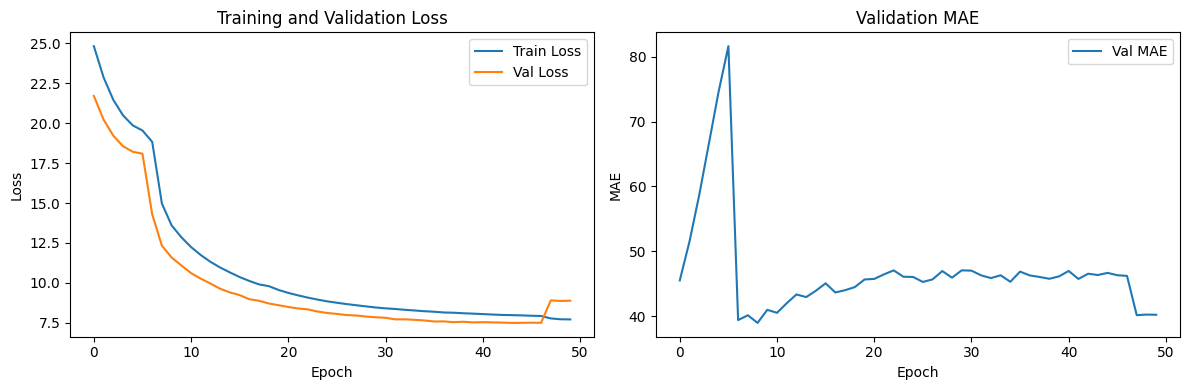

In [11]:
if(True):
    # Cell 7: Plot training metrics
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_maes, label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.title('Validation MAE')
    plt.tight_layout()
    plt.show()

    # Save the model
    torch.save(model.state_dict(), 'transformer_model.pth')
    logger.info("Model saved as 'transformer_model.pth'")

In [ ]:
import os
import json
!pip install -q kaggle

# Create folder for upload
os.makedirs("model_upload", exist_ok=True)
os.rename("transformer_model.pth", "model_upload/transformer_model.pth")

# Replace with your actual dataset slug
dataset_slug = "ansersohaib566/glacier-model-checkpoints"

# Create metadata for Kaggle
metadata = {
    "title": "Glacier Model Checkpoints",
    "id": dataset_slug,
    "licenses": [{"name": "CC0-1.0"}]
}
with open("model_upload/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)

# Upload to Kaggle Dataset
!kaggle datasets version -p model_upload -m "Updated model checkpoint"


In [13]:
# Load model state dict
model.load_state_dict(torch.load("/kaggle/working/transformer_model.pth", map_location=device))
model.eval()  # Set to evaluation mode

/tmp/ipykernel_73/301087312.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/transformer_model.pth", map_location=device

DataParallel(
  (module): TransformerRegressor(
    (embedding): Linear(in_features=8, out_features=512, bias=True)
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (fc): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [ ]:
import pandas as pd
import numpy as np
# testdf = pd.read_csv("/kaggle/working/data/df_raw.csv", usecols=["lat", "lon", "mid_date", "v [m/yr]"])
import pandas as pd

# First ensure mid_date is a datetime type (if it isn't already)
testdf['mid_date'] = pd.to_datetime(testdf['mid_date'])

# Filter for dates between 2000-01-01 and 2021-12-31
testdf = testdf[(testdf['mid_date'] >= '2021-12-31') & (testdf['mid_date'] <= '2022-12-31')]

# Display the filtered data
print(f"Original data points: {len(testdf)}")
testdf.head()
testdf = investigate_and_summarize_velocity(testdf)


In [16]:
testdf

,lon,lat,year,month_sin,month_cos,day_sin,day_cos,avg_velocity,max_velocity
0,74.353,36.182,2021,-2.449294e-16,1.000000,-2.449294e-16,1.000000,3.666667,24.0
1,74.353,36.182,2022,5.000000e-01,0.866025,3.943559e-01,0.918958,9.387097,135.0
2,74.353,36.182,2022,5.000000e-01,0.866025,5.712682e-01,0.820763,7.285714,16.0
3,74.353,36.182,2022,5.000000e-01,0.866025,8.486443e-01,0.528964,2.454545,10.0
4,74.353,36.182,2022,5.000000e-01,0.866025,9.377521e-01,0.347305,9.300000,29.0
...,...,...,...,...,...,...,...,...,...
747166,74.540,36.323,2022,-2.449294e-16,1.000000,-9.884683e-01,0.151428,12.818182,86.0
747167,74.540,36.323,2022,-2.449294e-16,1.000000,-9.377521e-01,0.347305,4.125000,22.0
747168,74.540,36.323,2022,-2.449294e-16,1.000000,-8.486443e-01,0.528964,7.533333,83.0
747169,74.540,36.323,2022,-2.449294e-16,1.000000,-5.712682e-01,0.820763,6.379310,83.0


In [17]:
test_size = len(testdf)
testdata = TimeSeriesDataset(testdf, SEQ_LENGTH)
test_loader = DataLoader(testdata, batch_size=BATCH_SIZE, shuffle=False, num_workers=12, pin_memory = True)

# Cell 8: Evaluate on test set
model.eval()
test_loss, test_mae = 0, 0
with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Testing"):
        X, y = X.to(device), y.to(device)
        output = model(X)
        test_loss += criterion(output.squeeze(), y).item()
        test_mae += torch.mean(torch.abs(output.squeeze() - y)).item()

test_loss /= len(test_loader)
test_mae /= len(test_loader)
logger.info(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

Testing:   0%|          | 0/183 [00:00<?, ?it/s]


InvalidIndexError: Caught InvalidIndexError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 173, in pandas._libs.index.IndexEngine.get_loc
TypeError: '(slice(0, 32, None), slice(None, -1, None))' is an invalid key

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched

In [19]:
import numpy as np
import torch

predictions = []
actuals = []
n = 10  # Number of predictions to make
i = 0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # Convert to numpy and store
        for j in range(len(outputs)):
            if i >= n:  # Stop after 10 predictions
                break
            predictions.append(outputs[j].cpu().numpy())
            actuals.append(targets[j].cpu().numpy())
            i += 1
        if i >= n:
            break  # Exit the outer loop once we have 10 samples

# Convert to numpy arrays
predictions = np.array(predictions)
actuals = np.array(actuals)

# **Inverse transform predictions**
predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1))
actuals = scaler_y.inverse_transform(actuals.reshape(-1, 1))

InvalidIndexError: Caught InvalidIndexError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 173, in pandas._libs.index.IndexEngine.get_loc
TypeError: '(slice(0, 32, None), slice(None, -1, None))' is an invalid key

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched

In [ ]:
print("Unscaled Predictions:", predictions[:10])
print("Unscaled Actuals:", actuals[:10])

In [ ]:
import torch
import numpy as np
import pandas as pd
from datetime import datetime

def to_ordinal(x):
    """Converts datetime string to ordinal format with fractional day."""
    x = pd.to_datetime(x)  # Convert string to datetime
    return x.toordinal() + (x.hour * 3600 + x.minute * 60 + x.second) / 86400.0

# Define your input values
time = '2022-04-04 01:07:06.856773120'
lat = 36.317
lon = 74.4637

# Convert time to ordinal
ordinal_time = to_ordinal(time)

# Convert to a NumPy array
new_input = np.array([[ordinal_time, lat, lon]])

# Scale using the same scaler used for training
new_input_scaled = scaler_X.transform(new_input)

# Convert to PyTorch tensor
new_input_tensor = torch.tensor(new_input_scaled, dtype=torch.float32).to(device)

print("Processed Input Tensor:", new_input_tensor)


In [ ]:
# Reshape input to (batch_size=1, seq_length=1, feature_dim=3)
new_input_tensor = new_input_tensor.unsqueeze(0)  

with torch.no_grad():
    vel_predicted = model(new_input_tensor).cpu().numpy()  # Convert tensor to NumPy

# Inverse transform to get the original velocity value
vel_predicted_original = scaler_y.inverse_transform(vel_predicted.reshape(-1, 1))

print(f"Predicted Velocity: {vel_predicted_original[0][0]:.4f} m/yr")
